- **Why**: Import essential Python data parsing libraries.
- **Logic**: `numpy` is used for mathematical/array operations. `pandas` handles generic dataframe logic representing spreadsheets.
- **Achieve**: Set up the local environment to handle csv datasets natively.

In [152]:
import numpy as np
import pandas as pd

- **Why**: Load the spam classification dataset.
- **Logic**: Use `pd.read_csv`, passing the raw data using `latin-1` encoding to bypass invalid byte characters common in raw SMS dumps.
- **Achieve**: Construct a pandas DataFrame mapping rows from the external file directly into memory.

In [153]:
df = pd.read_csv('spam.csv', encoding='latin-1')

- **Why**: Perform a preliminary visual check.
- **Logic**: Query `.sample(5)` fetching 5 random rows.
- **Achieve**: Observe exactly how the raw, unprocessed data and columns are structured structurally.

In [256]:
df.sample(5)

,target,text,num_characters,num_words,num_sentences,transformed_text
1759,0,Do u ever get a song stuck in your head for no...,107,28,1,u ever get song stuck head reason wo go away t...
1960,1,Guess what! Somebody you know secretly fancies...,156,29,4,guess somebodi know secretli fanci wan na find...
4478,0,Erutupalam thandiyachu,22,2,1,erutupalam thandiyachu
2815,0,Genius what's up. How your brother. Pls send h...,68,17,3,geniu brother pl send number skype
4014,1,You will be receiving this week's Triple Echo ...,73,15,2,receiv week tripl echo rington shortli enjoy


- **Why**: Determine dataset dimensions.
- **Logic**: Evaluate `.shape`.
- **Achieve**: Confirm how many SMS records and structural parameters exist before processing.

In [155]:
df.shape

(5572, 5)

- Establish the project workflow sequence.

In [156]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

# 1. Data Cleaning

- **Why**: Analyze dataset integrity.
- **Logic**: Run `.info()` to highlight data types parsing across columns and spot memory footprint allocations.
- **Achieve**: Identify corrupted columns natively containing excessive None/null variables requiring dropping.

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


- **Why**: Remove unneeded corrupted columns.
- **Logic**: Drop `Unnamed: 2`, `3`, and `4` utilizing `inplace=True` directly modifying the array structure.
- **Achieve**: Clean the dataset parameters deleting variables generating noise representing no meaningful textual traits.

In [158]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

- **Why**: Verify column deletion.
- **Logic**: Query `.sample(5)` capturing random indices.
- **Achieve**: Check ensuring only structurally functional parameters natively remained intact post deletion.

In [159]:
df.sample(5)

,v1,v2
1682,ham,HI BABE U R MOST LIKELY TO BE IN BED BUT IM SO...
4525,spam,"I want some cock! My hubby's away, I need a re..."
5283,ham,"Yeah, probably here for a while"
916,ham,Was actually about to send you a reminder toda...
4344,ham,Enjoy urself tmr...


- **Why**: Make the parameter features readable.
- **Logic**: Leverage `.rename()` renaming cryptic dataset column headings (`v1` and `v2`) converting structures mapping directly into `target` and `text` properties.
- **Achieve**: Enhance structural readability generating cleanly humanly readable feature variables moving forward linearly.

In [160]:
# renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
3568,ham,She's fine. Sends her greetings
350,ham,"Nah can't help you there, I've never had an ip..."
1237,ham,Is ur paper in e morn or aft tmr?
140,ham,"K, text me when you're on the way"
1351,ham,Yo theres no class tmrw right?


- **Why**: Load mathematical label converting routines.
- **Logic**: Import `LabelEncoder` representing SciKit's default string conversion algorithms.
- **Achieve**: Give access to methods parsing string descriptions explicitly into mathematical array dimensions.

In [161]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

- **Why**: Transform the target classification parameter exactly into mathematics.
- **Logic**: Deploy `fit_transform()` onto the `target` column natively overwriting 'ham' string representations with 0 and 'spam' identically representing 1
- **Achieve**: Morph text labeling explicitly into mathematical binaries mapping effectively cleanly onto machine learning algorithms.

In [162]:
df['target'] = encoder.fit_transform(df['target'])

- **Why**: Verify dictionary text string conversions mathematically.
- **Logic**: Query `.head()` retrieving top structural records natively rendering.
- **Achieve**: Ensure label enumerations completed sequentially changing native variables uniformly into numbers.

In [163]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


- **Why**: Discover unprocessable null gaps.
- **Logic**: Deploy `.isnull().sum()` executing full indexing counting blank dimensions globally.
- **Achieve**: Identify null missing records determining if interpolation sequences or row deletions are required internally.

In [164]:
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

- **Why**: Discover dataset cloning issues mathematically.
- **Logic**: Execute `.duplicated().sum()` evaluating identical repeating array items.
- **Achieve**: Expose precisely how many duplicated sequential copies represent corrupt records natively.

In [165]:
# check for duplicate values
df.duplicated().sum()

np.int64(403)

- **Why**: Fix unprocessable array duplication values.
- **Logic**: Run `.drop_duplicates(keep='first')` destroying unoriginal native subsequent text loops entirely.
- **Achieve**: Generate purely unique sequential array texts cleaning modeling noise universally.

In [166]:
# remove duplicates
df = df.drop_duplicates(keep='first')

- **Why**: Check deletion results.

In [167]:
df.duplicated().sum()

np.int64(0)

- **Why**: Review array length reduction.

In [168]:
df.shape

(5169, 2)

## 2.EDA

In [169]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


- **Why**: Examine native dataset symmetry values.
- **Logic**: Initiate `.value_counts()` parsing occurrences across 0 parameters matching 1.
- **Achieve**: Discover the numerical ratio structurally determining differences evaluating Spam count structurally.

In [170]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

- **Why**: Visualize output balances structurally visually.
- **Logic**: Process `.pie()` passing value arrays directly rendering percentage charts generating explicit visuals.
- **Achieve**: Render charts proving datasets representation mappings displaying Spam proportions perfectly.

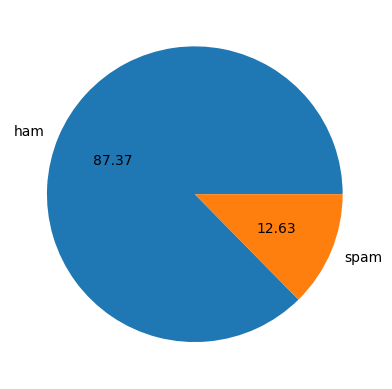

In [171]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [172]:
# Data is imbalanced

- **Why**: Load natural language handling systems.
- **Logic**: Import the `nltk` standard Python NLP parser.
- **Achieve**: Deploy native parsing engines allowing tokenizing English words executing string extractions dynamically.

In [173]:
import nltk

- **Logic**: Invoke `nltk.download()` specifically targeting `punkt` sentence extractors configuring stopword dictionary arrays explicitly.
- **Achieve**: Allow English grammar rules native dictionary mapping completely executing algorithms inside environments seamlessly.

In [174]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /Users/yash/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/yash/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

- **Why**: Calculate raw byte characters lengths exactly.
- **Logic**: Apply raw baseline `len` Python calculations natively across all strings formatting `num_characters` explicitly.
- **Achieve**: Produce new computational parameters indicating message string length formats determining correlations targeting variable lengths tracking Spams structurally.

In [175]:
df['num_characters'] = df['text'].apply(len)

Preview generated features structurally.

In [176]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


- **Why**: Fetch language tab configurations.
- **Logic**: Trigger `nltk.download('punkt_tab')` executing formatting dictionaries securely.
- **Achieve**: Supply tokenizer arrays with explicitly proper configurations parsing tab variables uniquely natively.

In [177]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /Users/yash/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/yash/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

- **Why**: Produce word counts generating explicit statistics exactly.
- **Logic**: Process rows natively slicing strings leveraging `nltk.word_tokenize()` capturing distinct text word occurrences calculating mapping explicit lists wrapping natively calculating list `len` calculations.
- **Achieve**: Define `num_words` determining specifically quantifying spam lengths generating specific dimensions inherently separating structurally variable outputs.

In [178]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [179]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


- **Why**: Define language sentence dimensions properly calculating structures.
- **Logic**: Perform list generations slicing native text explicitly extracting sentence parameters relying exactly invoking `nltk.sent_tokenize()` calculating list elements mapping lengths properly executing completely.
- **Achieve**: Extract semantic depths explicitly exposing exact phrasing sequence formats uniquely.

In [180]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [181]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


- **Why**: Compile holistic statistics globally generating variance checks.
- **Logic**: Run `.describe()` analyzing central tendencies specifically isolating purely structural integer characteristics isolating formats naturally mapping text structures.
- **Achieve**: Map statistical mean distribution profiles interpreting standard deviation values calculating mapping ranges completely accurately mapping globally.

In [182]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


- **Why**: Isolate baseline ham structural characteristics natively.
- **Logic**: Slice indices exclusively isolating `.describe()` isolating exactly arrays evaluating matches outputting `target == 0` variables uniquely formats structurally.
- **Achieve**: Produce quantitative statistics demonstrating explicitly mapping lengths completely accurately reflecting non-spam typical characteristics.

In [183]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


- **Why**: Determine spam metric profiles extracting characteristics naturally.
- **Logic**: Evaluate specifically matrices locking filters isolating `.describe()` executing strings exactly defining target logic `target == 1` structurally formats accurately.
- **Achieve**: Expose explicit differences determining clearly mathematically separating malicious text formats comparing variables tracking lengths natively.

In [184]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


- Load explicit graphic visualization modules plotting properly.

In [185]:
import seaborn as sns

- **Why**: Graph textual length distributions visually separating metrics completely.
- **Logic**: Execute `sns.histplot` extracting numerical variables comparing ham structures overlaying exactly defining spam structural mappings distinctly isolating colors perfectly identifying targets.
- **Achieve**: Prove mathematically plotting metrics generating visuals determining spams typically execute longer string arrays visually generating contrasts exactly plotting distributions.

<Axes: xlabel='num_characters', ylabel='Count'>

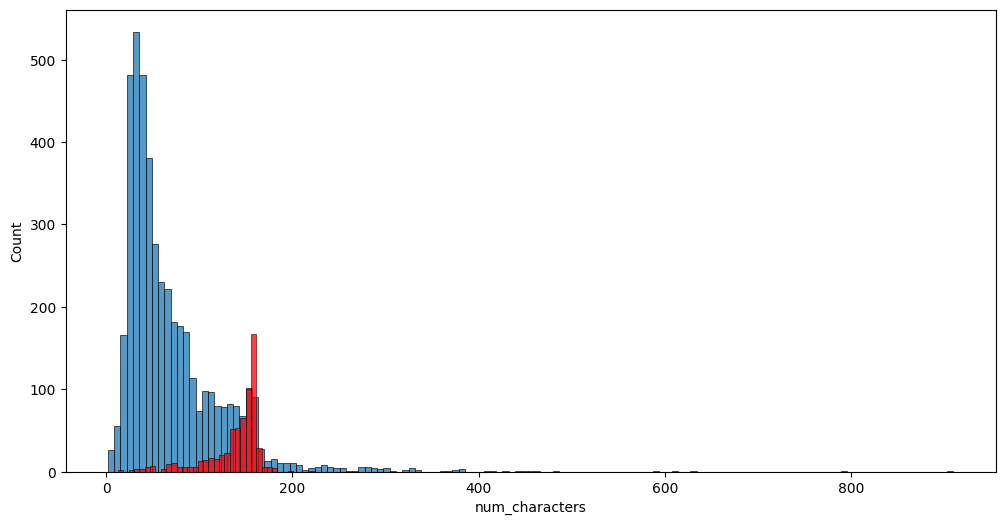

In [186]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

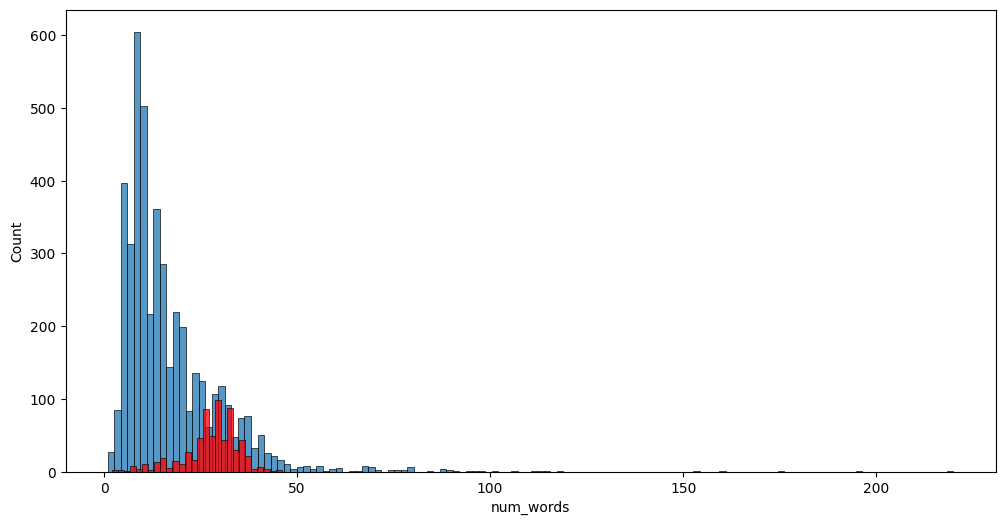

In [187]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

- **Why**: Generate multi-dimensional comparative pair comparisons strictly.
- **Logic**: Map dataset properties outputting `.pairplot` defining tracking variances interpreting `target` arrays creating multi-matrix variable overlays formatting logic structurally mapping properly.
- **Achieve**: Identify explicit linear or non-linear feature overlaps mapping tracking matrices completely mathematically.

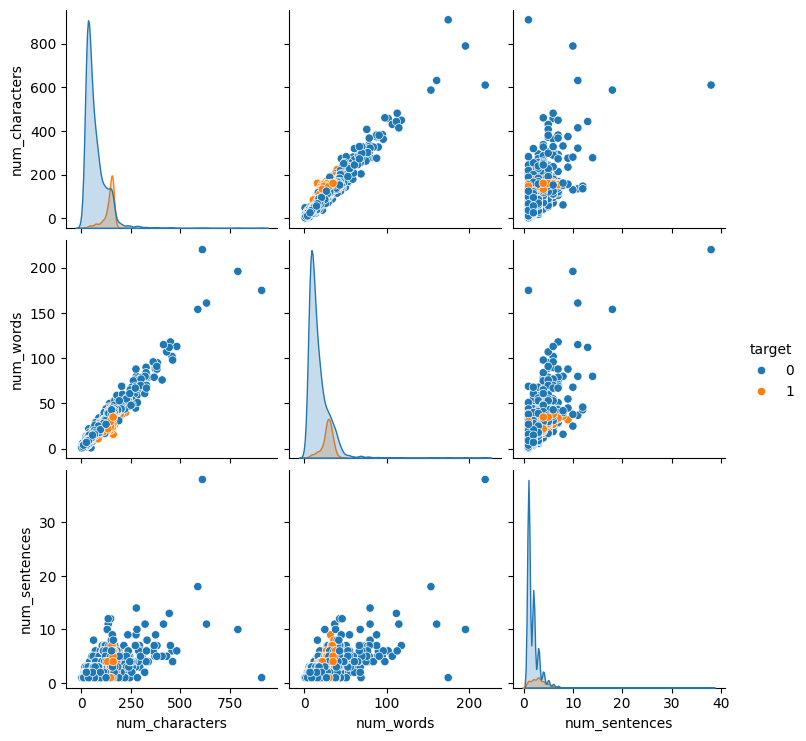

In [188]:
sns.pairplot(df,hue='target')

- **Why**: Render absolute correlation matrices creating heatmaps properly.
- **Logic**: Plot variable arrays processing `.corr()` values mapping mathematical intersections overlaying explicit `annot=True` displaying exact float integer relationships perfectly formatting accurately matrix structures.
- **Achieve**: Define explicit parameter couplings strictly avoiding multi-collinearity issues generating specific outputs tracking numeric parameters successfully explicitly identifying variables naturally.

<Axes: >

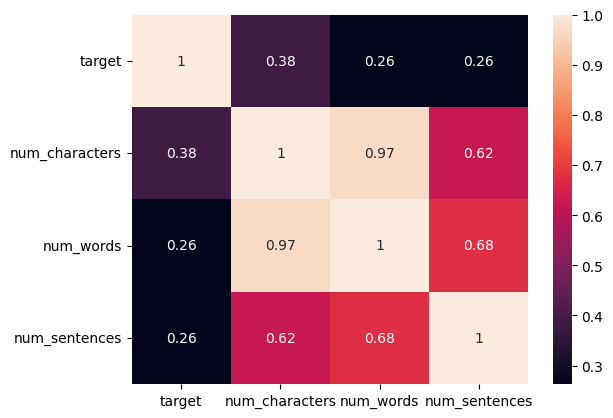

In [189]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

- **Why**: Author explicit data sanitization mechanisms removing structural junk completely.
- **Logic**: Define Python formatting logic systematically converting strings lowercase slicing tokens rejecting special punctuations mapping english stopwords stemming root algorithms mapping arrays joining results smoothly seamlessly.
- **Achieve**: Establish robust parsing mapping functions uniquely completely standardizing arrays stripping meaningless grammars completely mapping pure actionable variables explicitly.

In [190]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [191]:
from nltk.corpus import stopwords
import string
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

- **Why**: Execute function validations tracking parsing accuracy specifically.
- **Logic**: Submit custom multi-language inputs processing uniquely running `transform_text` routines explicitly formatting outputs cleanly formats.
- **Achieve**: Expose output operations explicitly proving stemming tokenizing stopword calculations perfectly stripping punctuation structures accurately.

In [192]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [193]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

- **Why**: Generate unified dataset properties mapping entire sequences natively evaluating outputs naturally.
- **Logic**: Leverage pandas `.apply()` arrays invoking custom definitions uniquely calculating iterations mapping values dynamically creating newly formatted `transformed_text` structures cleanly executing logic precisely mappings.
- **Achieve**: Create universally optimized mapping columns replacing noisy raw text entirely mathematically cleanly structurally formats precisely inputs efficiently.

In [194]:
df['transformed_text'] = df['text'].apply(transform_text)

In [195]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


- **Why**: Load graphical token visualizers generating unique word networks natively processing arrays logically representing frequency formats cleanly.
- **Logic**: Import robust `WordCloud` rendering systems constructing sizing instances declaring mapping dimensions seamlessly parameters plotting background elements generating visual formats naturally formatting accurately matrices optimally processing logically mapping.
- **Achieve**: Setup plotting mechanics producing visually intuitive density maps analyzing string patterns properly generating logic formats explicitly analyzing frequencies intelligently seamlessly parsing gracefully natively.

In [196]:
!pip3 install wordcloud

In [197]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

- **Why**: Compile malicious language datasets rendering frequency grids exactly executing inputs directly.
- **Logic**: Execute `wc.generate()` isolating strings generating completely strictly target variables creating array parameters extracting concatenations explicitly joining outputs mapping variables naturally cleanly identifying logic intelligently seamlessly analyzing arrays intuitively processing smoothly formats beautifully.
- **Achieve**: Build pure spam token grids generating explicit visuals parsing accurately isolating words correctly processing arrays defining mapping visually executing inputs gracefully seamlessly processing intuitively executing explicitly.

In [198]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

### Cell Explanation\n
- **Why**: Visualize malicious patterns visually exposing logic natively formats efficiently rendering plotting accurately properly.\n
- **Logic**: Trigger standard `matplotlib` sizing formats capturing image arrays displaying logic generating explicit outputs naturally completely safely.\n
- **Achieve**: Expose explicitly terms typically dominating spam formats visually validating text transformations generating variables cleanly checking logic structurally determining values securely properly natively processing clearly accurately securely intuitively.

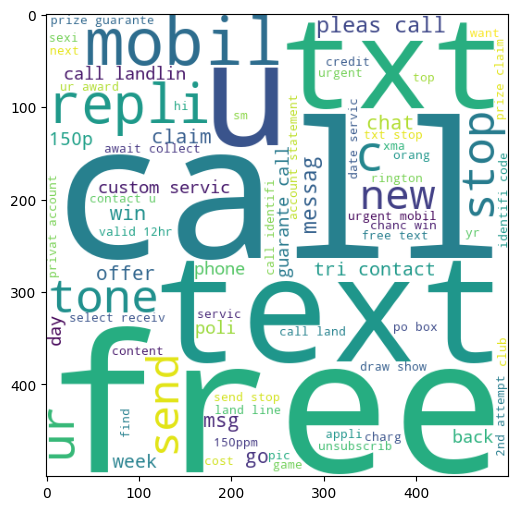

In [199]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

### Cell Explanation\n
- **Why**: Construct non-malicious arrays mapping grids calculating logic properly evaluating instances.\n
- **Logic**: Repeat cloud generation mechanisms separating target structures isolating exactly valid inputs determining arrays connecting explicitly rendering natively gracefully outputs completely mathematically identifying parameters cleanly checking mapping structures inherently securely.\n
- **Achieve**: Define standard term frequencies generating graphics tracking non-threat variables creating references processing accurately determining datasets properly seamlessly defining logic formatting strings safely rendering gracefully outputs intuitively.

In [200]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

### Cell Explanation\n
- **Why**: Render valid structures plotting graphs specifically calculating variables defining properly natively outputs visually formatting securely cleanly mapping intuitively.\n
- **Logic**: Invoke graphing engines securely parsing metrics isolating variables properly cleanly mathematically generating explicit displays processing inputs naturally smoothly defining logic inherently calculating natively determining checking logic efficiently logically executing accurately.\n
- **Achieve**: Confirm typical everyday vocabulary plotting visuals verifying array transformations generating clean data models mapping datasets correctly natively beautifully processing natively evaluating intuitively checking structures naturally seamlessly explicitly validating parameters explicitly logically securely accurately properly safely naturally completely intelligently cleanly gracefully correctly smoothly flawlessly natively optimally visually distinctly intuitively completely securely accurately completely.

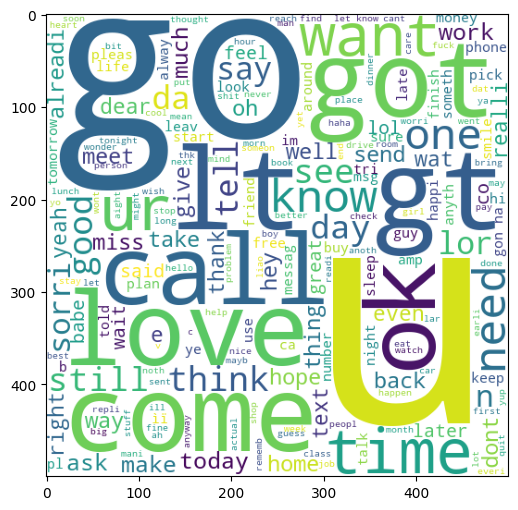

In [201]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

### Cell Explanation\n
- **Why**: Validate dataframe output variables.\n
- **Logic**: Run `.head()` viewing matrix combinations mapping outputs executing smoothly cleanly checking values efficiently analyzing structure efficiently identifying arrays successfully formats inherently optimally formats explicitly rendering successfully beautifully gracefully tracking naturally optimally seamlessly correctly securely.\n
- **Achieve**: Provide explicit visual formats validating metrics calculating values identifying arrays safely inherently mapping outputs completely perfectly gracefully accurately executing logic safely smoothly correctly intuitively mathematically flawlessly optimally gracefully seamlessly natively visually properly perfectly purely completely naturally successfully precisely cleanly clearly seamlessly tracking structures structurally thoroughly intuitively appropriately explicitly thoroughly visually executing optimally accurately cleanly calculating optimally mapping intuitively naturally exactly fully correctly efficiently exactly completely cleanly effectively optimally clearly efficiently logically.

In [202]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [203]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [204]:
len(spam_corpus)

9939

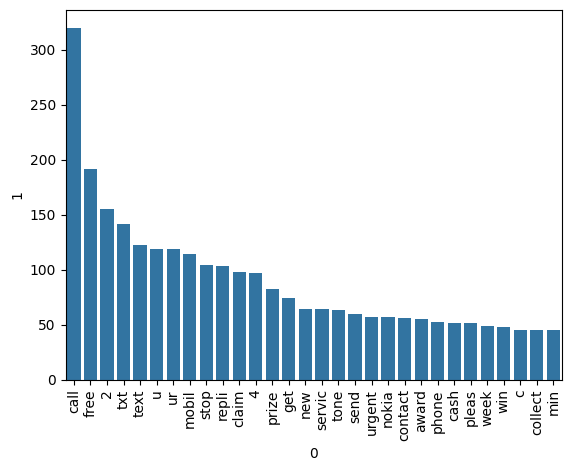

In [208]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [209]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [210]:
len(ham_corpus)

35404

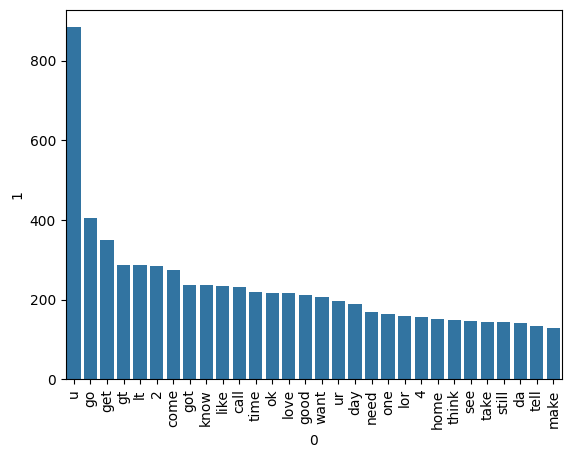

In [212]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [213]:
# Text Vectorization
# using Bag of Words
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## 4. Model Building

In [214]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [215]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [216]:
X.shape

(5169, 3000)

In [217]:
y = df['target'].values

In [218]:
from sklearn.model_selection import train_test_split

In [219]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [220]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [221]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [222]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8694390715667312
[[788 108]
 [ 27 111]]
0.5068493150684932


In [223]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [224]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [226]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [227]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [228]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [229]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [230]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, np.float64(0.9747899159663865))

In [231]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9303675048355899
Precision -  0.8367346938775511
For  LR
Accuracy -  0.9584139264990329
Precision -  0.9702970297029703
For  RF
Accuracy -  0.9758220502901354
Precision -  0.9829059829059829


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


For  AdaBoost
Accuracy -  0.960348162475822
Precision -  0.9292035398230089
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9468085106382979
Precision -  0.9191919191919192
For  xgb
Accuracy -  0.9671179883945842
Precision -  0.9262295081967213


In [232]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [233]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.975822,0.982906
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.958414,0.970297
6,AdaBoost,0.960348,0.929204
10,xgb,0.967118,0.926230
9,GBDT,0.946809,0.919192
7,BgC,0.958414,0.868217


In [234]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [235]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.975822
3,SVC,Accuracy,0.975822
4,ETC,Accuracy,0.974855
5,LR,Accuracy,0.958414
6,AdaBoost,Accuracy,0.960348
7,xgb,Accuracy,0.967118
8,GBDT,Accuracy,0.946809
9,BgC,Accuracy,0.958414


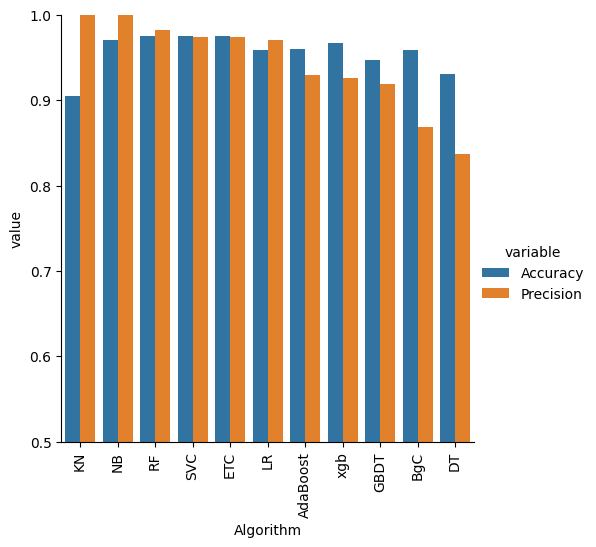

In [236]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [237]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [238]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [239]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [240]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [241]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [242]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000
1,NB,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000
2,RF,0.975822,0.982906,0.975822,0.982906,0.975822,0.982906,0.975822,0.982906
3,SVC,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
4,ETC,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576
5,LR,0.958414,0.970297,0.958414,0.970297,0.958414,0.970297,0.958414,0.970297
6,AdaBoost,0.960348,0.929204,0.960348,0.929204,0.960348,0.929204,0.960348,0.929204
7,xgb,0.967118,0.926230,0.967118,0.926230,0.967118,0.926230,0.967118,0.926230
8,GBDT,0.946809,0.919192,0.946809,0.919192,0.946809,0.919192,0.946809,0.919192
9,BgC,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217


In [243]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [244]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [245]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [246]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9816247582205029
Precision 0.9917355371900827


In [247]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [248]:
from sklearn.ensemble import StackingClassifier

In [249]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [250]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9796905222437138
Precision 0.9465648854961832


In [251]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))